In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
%matplotlib inline

In [22]:
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)
!unzip -q hw_pro.zip

replace hw_pro/0/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace hw_pro/0/10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [23]:
base_dir = '/content/hw_pro'
x_train = []
y_train = []
img_height = 20
img_width = 20

for patch in os.listdir(base_dir):
    for img in os.listdir(base_dir + '/' + patch):
        img_path = base_dir + '/' + patch + '/' + img
        image = Image.open(img_path).convert('L')  # grayscale
        image = image.resize((img_height, img_width))
        img_array = np.array(image, dtype=np.float32) / 255.0
        x_train.append(img_array)

        if patch == '0':
            y_train.append(0)  # нолик
        else:
            y_train.append(1)  # крестик

x_train = np.array(x_train).reshape(-1, 1, 20, 20)
y_train = np.array(y_train)

print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

# Разделение на train и validation
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Преобразование в тензоры PyTorch
x_train_tensor = torch.FloatTensor(x_train)
y_train_tensor = torch.LongTensor(y_train)
x_val_tensor = torch.FloatTensor(x_val)
y_val_tensor = torch.LongTensor(y_val)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Размер массива x_train (102, 1, 20, 20)
Размер массива y_train (102,)


In [24]:
class TicTacToeModel(nn.Module):
    def __init__(self):
        super(TicTacToeModel, self).__init__()
        self.fc1 = nn.Linear(400, 64)
        self.fc2 = nn.Linear(64, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 400)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TicTacToeModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
epochs = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss/len(val_loader))
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

# Сохранение весов
torch.save(model.state_dict(), 'pro.pth')
print("Веса сохранены в pro.pth")

Epoch 1/20, Train Loss: 0.7367, Train Acc: 0.5309, Val Acc: 0.6190
Epoch 2/20, Train Loss: 0.7147, Train Acc: 0.4815, Val Acc: 0.6667
Epoch 3/20, Train Loss: 0.6564, Train Acc: 0.5432, Val Acc: 0.3810
Epoch 4/20, Train Loss: 0.6352, Train Acc: 0.5309, Val Acc: 0.5714
Epoch 5/20, Train Loss: 0.5940, Train Acc: 0.8519, Val Acc: 0.8095
Epoch 6/20, Train Loss: 0.5692, Train Acc: 0.9136, Val Acc: 0.8095
Epoch 7/20, Train Loss: 0.5424, Train Acc: 0.9630, Val Acc: 0.9048
Epoch 8/20, Train Loss: 0.5085, Train Acc: 0.9753, Val Acc: 0.9048
Epoch 9/20, Train Loss: 0.4910, Train Acc: 0.9630, Val Acc: 1.0000
Epoch 10/20, Train Loss: 0.4621, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 11/20, Train Loss: 0.4292, Train Acc: 0.9877, Val Acc: 0.9524
Epoch 12/20, Train Loss: 0.3942, Train Acc: 0.9753, Val Acc: 1.0000
Epoch 13/20, Train Loss: 0.3723, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 14/20, Train Loss: 0.3439, Train Acc: 1.0000, Val Acc: 1.0000
Epoch 15/20, Train Loss: 0.3131, Train Acc: 1.0000, Val A

In [26]:
print("Точность обучения:", history['train_acc'][-1])
print("Точность проверки:", history['val_acc'][-1])

Точность обучения: 1.0
Точность проверки: 1.0


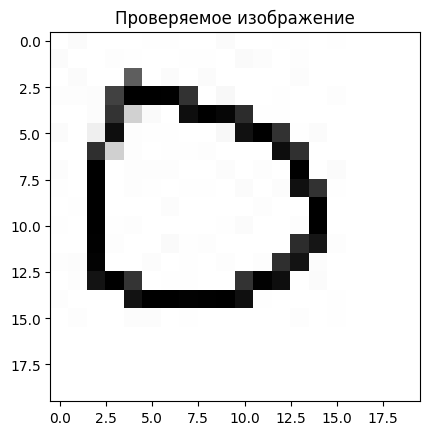

Нейросеть определила: НОЛИК


In [27]:
index = np.random.randint(0, len(x_train))

plt.imshow(x_train[index].reshape(20,20), cmap='gray')
plt.title("Проверяемое изображение")
plt.show()

model.eval()
with torch.no_grad():
    x_test = torch.FloatTensor(x_train[index]).unsqueeze(0).to(device)
    output = model(x_test)
    prediction = torch.nn.functional.softmax(output, dim=1)
    predicted_class = torch.argmax(prediction, dim=1).item()

if predicted_class == 0:
    print("Нейросеть определила: НОЛИК")
else:
    print("Нейросеть определила: КРЕСТИК")